# Predict Podcast Listening Time

## Playground Series - Season 5, Episode 4

### Dataset Description

The dataset for this competition (both train and test) was generated from a deep learning model trained on the Podcast Listening Time Prediction dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

**Evaluation Metric**: Root Mean Squared Error (RMSE)

In [1]:
%reload_ext cudf.pandas

In [2]:
!pip install lightgbm

In [42]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt

from tqdm import tqdm
from itertools import combinations
from cuml.preprocessing import TargetEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold

In [6]:
# Switch the docker directory to the current mounted directory.
# Originally at: /home/rapids/notebooks
import os

os.chdir("/home/rapids/eda/kaggle/playground/s5/e04/")
os.getcwd()

'/home/rapids/eda/kaggle/playground/s5/e04'

#### Visualisations

In [4]:
# Load the datasets
train, test = pd.read_csv("data/train.csv"), pd.read_csv("data/test.csv")

# Check the shapes of the datasets.
train.shape, test.shape

((750000, 12), (250000, 11))

In [6]:
# Check the information about the dataset.
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [7]:
# Check the statistical summary of the dataset.
train.describe().T.style.background_gradient(cmap='Pastel1')

,count,mean,std,min,25%,50%,75%,max
id,750000.000000,374999.500000,216506.495284,0.000000,187499.750000,374999.500000,562499.250000,749999.000000
Episode_Length_minutes,662907.000000,64.504738,32.969603,0.000000,35.730000,63.840000,94.070000,325.240000
Host_Popularity_percentage,750000.000000,59.859901,22.873098,1.300000,39.410000,60.050000,79.530000,119.460000
Guest_Popularity_percentage,603970.000000,52.236449,28.451241,0.000000,28.380000,53.580000,76.600000,119.910000
Number_of_Ads,749999.000000,1.348855,1.151130,0.000000,0.000000,1.000000,2.000000,103.910000
Listening_Time_minutes,750000.000000,45.437406,27.138306,0.000000,23.178350,43.379460,64.811580,119.970000


In [8]:
# Check for missing values in the dataset.
train.isna().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

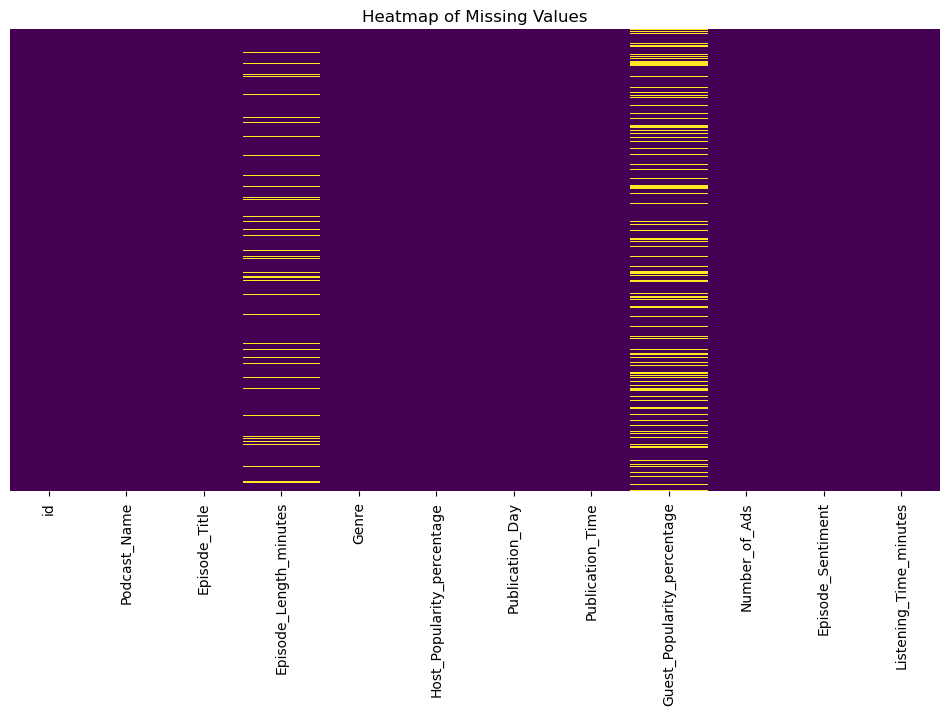

In [9]:
# Heatmap to visualize missing values.

plt.figure(figsize=(12, 6))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Heatmap of Missing Values")
plt.show()

In [10]:
num_cols = train.select_dtypes(exclude='object').columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()
target = num_cols[-1]

# Cleaning up the features
num_cols.remove('id')
num_cols.remove(target)

print("Number of numeric columns: ", len(num_cols))
print("Numerical columns: ", num_cols)

print("Number of categorical columns: ", len(cat_cols))
print("Categorical columns: ", cat_cols)

Number of numeric columns:  4
Numerical columns:  ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']
Number of categorical columns:  6
Categorical columns:  ['Podcast_Name', 'Episode_Title', 'Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']


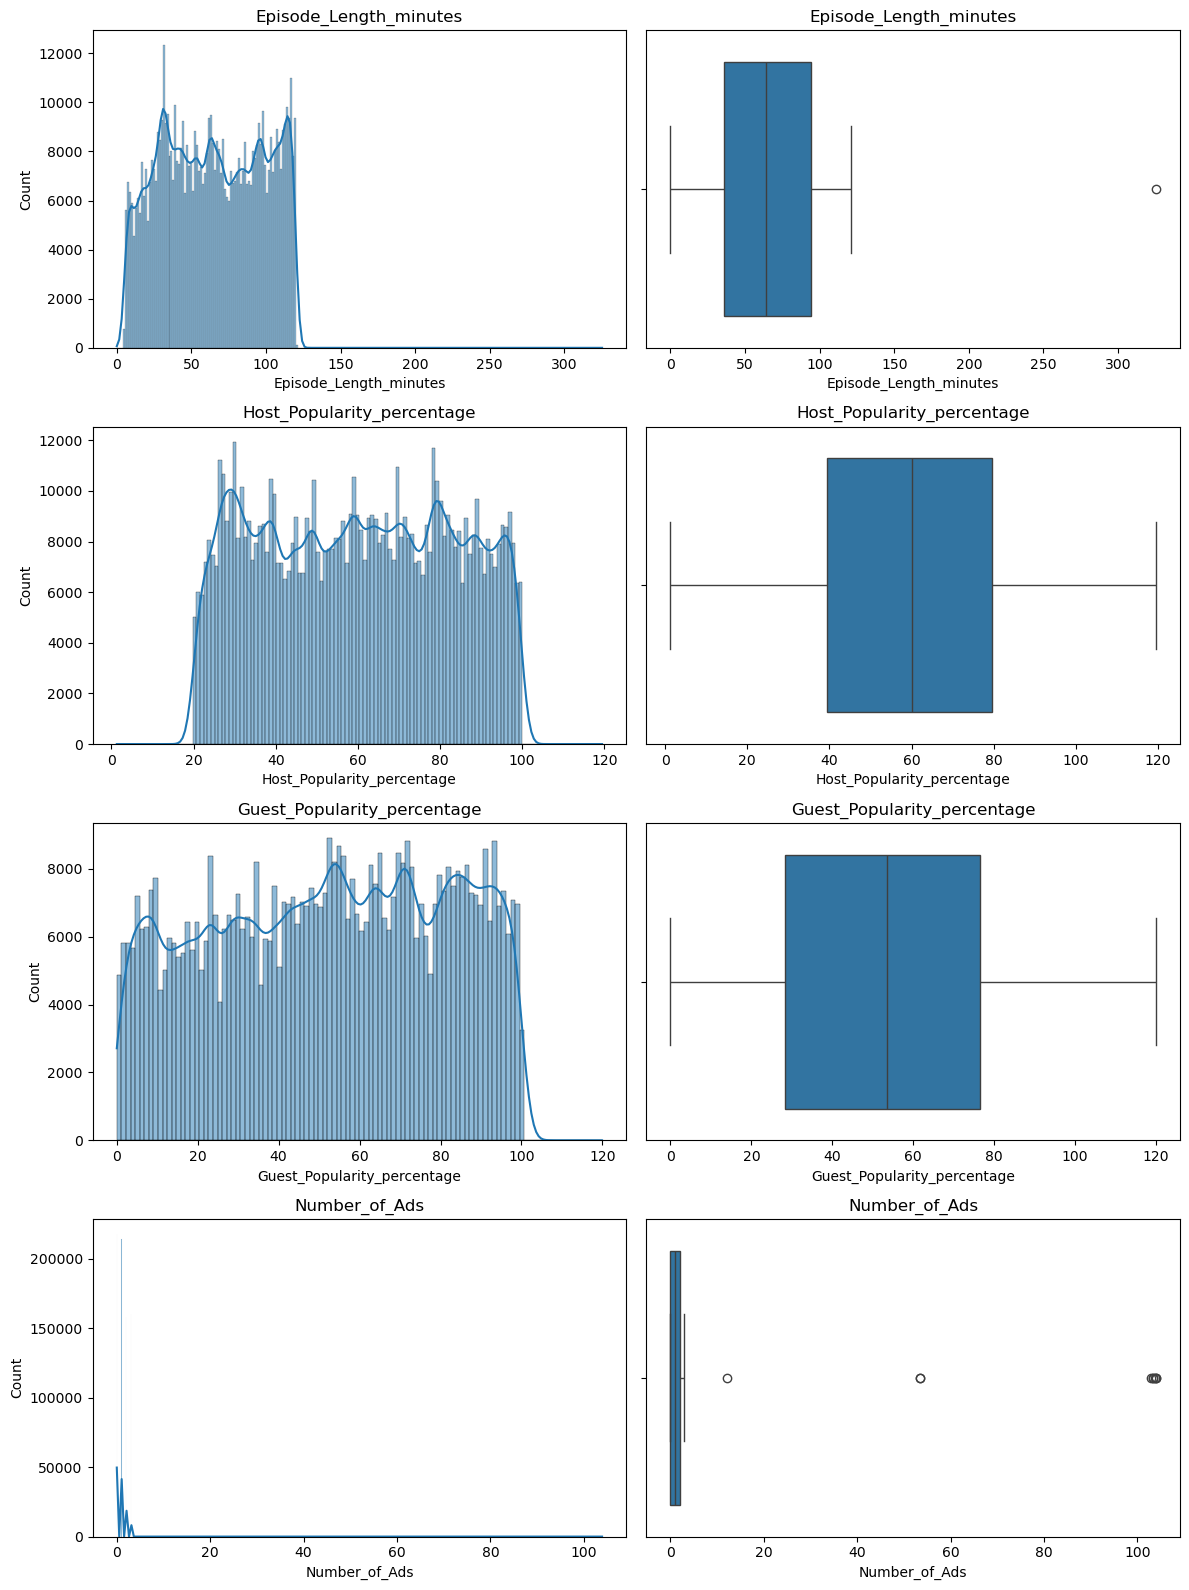

In [11]:
# Plot histogram and boxplot of numerical features.

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(train[col], kde=True, ax=axes[2 * i])
    axes[2 * i].set_title(col)

    sns.boxplot(train[col], ax=axes[2 * i + 1], orient='h')
    axes[2 * i + 1].set_title(col)

plt.tight_layout()
plt.show()

In [12]:
# Display the unique values and top 5 most frequent categories for categorical features.

for col in cat_cols:
    print(f"Unique values in {col}: {train[col].nunique()}\n")
    print(f"Top 5 most frequent categories: \n{train[col].value_counts().head(5)}")
    print("---" * 20)

Unique values in Podcast_Name: 48

Top 5 most frequent categories: 
Podcast_Name
Tech Talks       22847
Sports Weekly    20053
Funny Folks      19635
Tech Trends      19549
Fitness First    19488
Name: count, dtype: int64
------------------------------------------------------------
Unique values in Episode_Title: 100

Top 5 most frequent categories: 
Episode_Title
Episode 71    10515
Episode 62    10373
Episode 31    10292
Episode 61     9991
Episode 69     9864
Name: count, dtype: int64
------------------------------------------------------------
Unique values in Genre: 10

Top 5 most frequent categories: 
Genre
Sports        87606
Technology    86256
True Crime    85059
Lifestyle     82461
Comedy        81453
Name: count, dtype: int64
------------------------------------------------------------
Unique values in Publication_Day: 7

Top 5 most frequent categories: 
Publication_Day
Sunday       115946
Monday       111963
Friday       108237
Wednesday    107886
Thursday     104360
Name: 

In [13]:
train[num_cols + [target]].dropna().corr().style.background_gradient(cmap='Greens')

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
Episode_Length_minutes,1.000000,0.021051,-0.009705,-0.051002,0.915462
Host_Popularity_percentage,0.021051,1.000000,0.023080,-0.021091,0.046111
Guest_Popularity_percentage,-0.009705,0.023080,1.000000,0.008209,-0.013251
Number_of_Ads,-0.051002,-0.021091,0.008209,1.000000,-0.115430
Listening_Time_minutes,0.915462,0.046111,-0.013251,-0.115430,1.000000


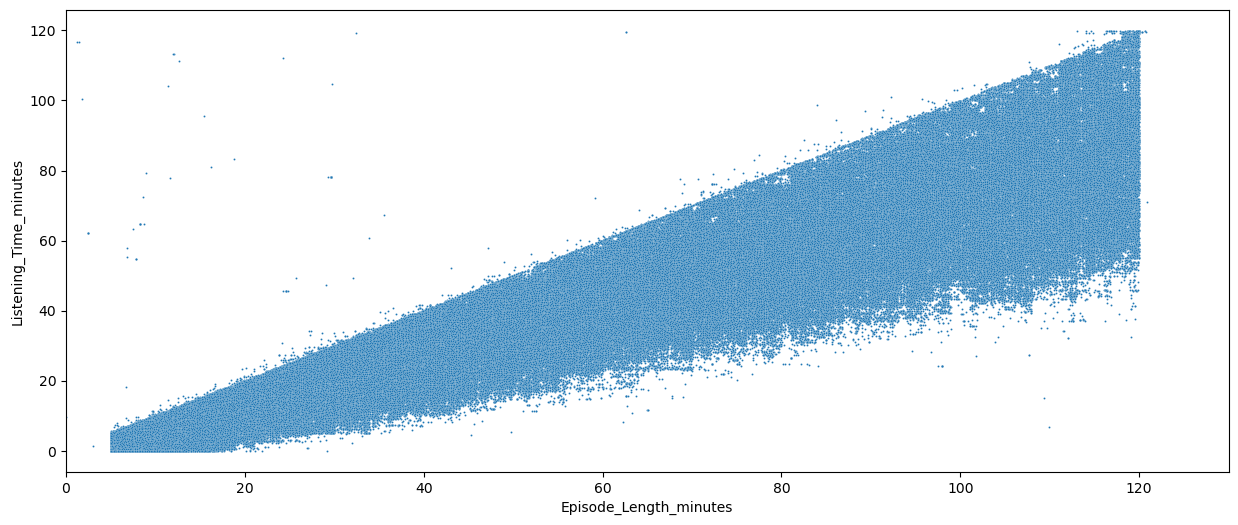

In [14]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x=num_cols[0], y=target, data=train, s=2)
plt.xlim(0, 130)
plt.show()

### [PS-S5E4 | LGBM CV 12.25 LB 12.15](https://www.kaggle.com/code/greysky/ps-s5e4-lgbm-cv-12-25-lb-12-15/notebook)

In [15]:
def feature_eng(df):
    podc_dict = {'Mystery Matters': 0, 'Joke Junction': 1, 'Study Sessions': 2, 'Digital Digest': 3, 'Mind & Body': 4, 'Fitness First': 5, 'Criminal Minds': 6, 'News Roundup': 7, 'Daily Digest': 8, 'Music Matters': 9, 'Sports Central': 10, 'Melody Mix': 11, 'Game Day': 12, 'Gadget Geek': 13, 'Global News': 14, 'Tech Talks': 15, 'Sport Spot': 16, 'Funny Folks': 17, 'Sports Weekly': 18, 'Business Briefs': 19, 'Tech Trends': 20, 'Innovators': 21, 'Health Hour': 22, 'Comedy Corner': 23, 'Sound Waves': 24, 'Brain Boost': 25, "Athlete's Arena": 26, 'Wellness Wave': 27, 'Style Guide': 28, 'World Watch': 29, 'Humor Hub': 30, 'Money Matters': 31, 'Healthy Living': 32, 'Home & Living': 33, 'Educational Nuggets': 34, 'Market Masters': 35, 'Learning Lab': 36, 'Lifestyle Lounge': 37, 'Crime Chronicles': 38, 'Detective Diaries': 39, 'Life Lessons': 40, 'Current Affairs': 41, 'Finance Focus': 42, 'Laugh Line': 43, 'True Crime Stories': 44, 'Business Insights': 45, 'Fashion Forward': 46, 'Tune Time': 47}
    genr_dict = {'True Crime': 0, 'Comedy': 1, 'Education': 2, 'Technology': 3, 'Health': 4, 'News': 5, 'Music': 6, 'Sports': 7, 'Business': 8, 'Lifestyle': 9}
    week_dict = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
    time_dict = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3}
    sent_dict = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
    
    df['Episode_Num'] = df['Episode_Title'].str[8:].astype('category')
    
    df['Genre'] = df['Genre'].replace(genr_dict)
    df['Podcast_Name'] = df['Podcast_Name'].replace(podc_dict)
    df['Publication_Day'] = df['Publication_Day'].replace(week_dict)
    df['Publication_Time'] = df['Publication_Time'].replace(time_dict)
    df['Episode_Sentiment'] = df['Episode_Sentiment'].replace(sent_dict)
    
    df['Genre'] = df['Genre'].astype('category')
    df['Podcast_Name'] = df['Podcast_Name'].astype('category')
    df['Publication_Day'] = df['Publication_Day'].astype('category')
    df['Publication_Time'] = df['Publication_Time'].astype('category')
    df['Episode_Sentiment'] = df['Episode_Sentiment'].astype('category')
    
    df = df.drop(columns=['Episode_Title'])
    return df

train_fe, test_fe = feature_eng(train), feature_eng(test)

/tmp/ipykernel_615/1889689800.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Genre'] = df['Genre'].replace(genr_dict)
/tmp/ipykernel_615/1889689800.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Podcast_Name'] = df['Podcast_Name'].replace(podc_dict)
/tmp/ipykernel_615/1889689800.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set

In [16]:
enc_cols = ['Episode_Length_minutes', 'Episode_Num', 'Host_Popularity_percentage', 'Number_of_Ads', 'Episode_Sentiment', 'Publication_Day', 'Publication_Time']
pair_size = [2, 3, 4]

for r in pair_size:
    for cols in tqdm(list(combinations(enc_cols, r))):
        new_col_name = '_'.join(cols)
        
        train_fe[new_col_name] = train_fe[list(cols)].astype(str).agg('_'.join, axis=1)
        train_fe[new_col_name] = train_fe[new_col_name].astype('category')
        
        test_fe[new_col_name] = test_fe[list(cols)].astype(str).agg('_'.join, axis=1)
        test_fe[new_col_name] = test_fe[new_col_name].astype('category')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [07:14<00:00, 12.42s/it]


In [17]:
X, y = train_fe.drop(columns='Listening_Time_minutes'), train_fe['Listening_Time_minutes']

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = np.zeros_like(len(test_fe))

for i, (train_idx, val_idx) in enumerate(cv.split(X)):
    print(f"Split {i+1} of 5")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test_fe[X.columns].copy()

    e_cols = X_train.columns[11:]
    enc = TargetEncoder(random_state=42)

    X_train[e_cols] = enc.fit_transform(X_train[e_cols], y_train)
    X_val[e_cols] = enc.transform(X_val[e_cols])
    X_test[e_cols] = enc.transform(X_test[e_cols])

    model = lgb.LGBMRegressor(
        n_iter=10, # Reduced due to resource scarcity
        num_leaves=64,
        learning_rate=0.03,
        max_depth=-1,
        colsample_bytree=0.7,
        objective='l2',
        metric='rmse',
        verbosity=-1,
        max_bin=64
    )

    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.log_evaluation(1)],
    )

    y_pred = model.predict(X_test)

Split 1 of 5


/tmp/ipykernel_615/63292490.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[e_cols] = enc.fit_transform(X_train[e_cols], y_train)
/tmp/ipykernel_615/63292490.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[e_cols] = enc.transform(X_val[e_cols])


[1]	valid_0's rmse: 26.5134
[2]	valid_0's rmse: 25.9096
[3]	valid_0's rmse: 25.3318
[4]	valid_0's rmse: 24.7707
[5]	valid_0's rmse: 24.2305
[6]	valid_0's rmse: 23.7105
[7]	valid_0's rmse: 23.2105
[8]	valid_0's rmse: 22.7315
[9]	valid_0's rmse: 22.2695
[10]	valid_0's rmse: 21.8256
Split 2 of 5


/tmp/ipykernel_615/63292490.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[e_cols] = enc.fit_transform(X_train[e_cols], y_train)
/tmp/ipykernel_615/63292490.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[e_cols] = enc.transform(X_val[e_cols])


[1]	valid_0's rmse: 26.5459
[2]	valid_0's rmse: 25.9419
[3]	valid_0's rmse: 25.3649
[4]	valid_0's rmse: 24.804
[5]	valid_0's rmse: 24.2641
[6]	valid_0's rmse: 23.7442
[7]	valid_0's rmse: 23.2431
[8]	valid_0's rmse: 22.7653
[9]	valid_0's rmse: 22.3037
[10]	valid_0's rmse: 21.8602
Split 3 of 5


...

[1]	valid_0's rmse: 26.5158
[2]	valid_0's rmse: 25.9128
[3]	valid_0's rmse: 25.3363
[4]	valid_0's rmse: 24.7769
[5]	valid_0's rmse: 24.2376
[6]	valid_0's rmse: 23.7185
[7]	valid_0's rmse: 23.219
[8]	valid_0's rmse: 22.7416
[9]	valid_0's rmse: 22.2812
[10]	valid_0's rmse: 21.8381
Split 4 of 5


/tmp/ipykernel_615/63292490.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[e_cols] = enc.fit_transform(X_train[e_cols], y_train)
/tmp/ipykernel_615/63292490.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[e_cols] = enc.transform(X_val[e_cols])


[1]	valid_0's rmse: 26.5759
[2]	valid_0's rmse: 25.9715
[3]	valid_0's rmse: 25.3939
[4]	valid_0's rmse: 24.8333
[5]	valid_0's rmse: 24.293
[6]	valid_0's rmse: 23.7734
[7]	valid_0's rmse: 23.2731
[8]	valid_0's rmse: 22.7943
[9]	valid_0's rmse: 22.3323
[10]	valid_0's rmse: 21.8878
Split 5 of 5


/tmp/ipykernel_615/63292490.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[e_cols] = enc.fit_transform(X_train[e_cols], y_train)
/tmp/ipykernel_615/63292490.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[e_cols] = enc.transform(X_val[e_cols])


[1]	valid_0's rmse: 26.4815
[2]	valid_0's rmse: 25.8774
[3]	valid_0's rmse: 25.2998
[4]	valid_0's rmse: 24.7392
[5]	valid_0's rmse: 24.1994
[6]	valid_0's rmse: 23.6795
[7]	valid_0's rmse: 23.1794
[8]	valid_0's rmse: 22.7009
[9]	valid_0's rmse: 22.2393
[10]	valid_0's rmse: 21.7959


### [xgboost single model](https://www.kaggle.com/code/pirhosseinlou/xgboost-single-model)

#### Load the data

In [4]:
# Load the datasets
train, test = pd.read_csv("data/train.csv"), pd.read_csv("data/test.csv")

# Check the shapes of the datasets.
train.shape, test.shape

((750000, 12), (250000, 11))

In [5]:
df = pd.concat([train, test], axis=0, ignore_index=True)

df.drop(columns=['id'], inplace=True)
df.drop_duplicates(inplace=True)

df.sample(5)

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
490019,Melody Mix,Episode 90,102.11,Music,60.06,Monday,Night,99.09,1.0,Positive,66.50469
804233,Global News,Episode 57,90.66,News,73.77,Wednesday,Afternoon,65.89,1.0,Positive,<NA>
725241,News Roundup,Episode 25,49.83,News,44.85,Wednesday,Evening,99.01,3.0,Neutral,28.56826
222836,Finance Focus,Episode 84,116.52,Business,47.98,Sunday,Afternoon,9.20,1.0,Neutral,61.31832
89500,Wellness Wave,Episode 71,102.41,Health,89.22,Friday,Morning,82.86,3.0,Negative,53.57831


#### Preprocessing

In [6]:
# Removing outliers
df['Episode_Length_minutes'] = np.maximum(0, np.minimum(120, df['Episode_Length_minutes']))
df['Host_Popularity_percentage'] = np.maximum(20, np.minimum(100, df['Host_Popularity_percentage']))
df['Guest_Popularity_percentage'] = np.maximum(0, np.minimum(100, df['Guest_Popularity_percentage']))

df.loc[df['Number_of_Ads'] > 3, 'Number_of_Ads'] = 0


# Encode categorical variables
day_mapping = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7}
df['Publication_Day'] = df['Publication_Day'].map(day_mapping)

time_mapping = {'Morning': 1, 'Afternoon': 2, 'Evening': 3, 'Night': 4}
df['Publication_Time'] = df['Publication_Time'].map(time_mapping)

sentiment_map = {'Negative': 1, 'Neutral': 2, 'Positive': 3}
df['Episode_Sentiment'] = df['Episode_Sentiment'].map(sentiment_map)

# Remove 'Episode ' from the titles and convert to integer
df['Episode_Title'] = df['Episode_Title'].str.replace('Episode ', '', regex=True)
df['Episode_Title'] = df['Episode_Title'].astype('int')


# Encode remaining categorical variables
enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = enc.fit_transform(df[col]) + 1

#### Feature Engineering

In [7]:
from tqdm.auto import tqdm

def process_combn_fast(df, enc_cols, pairings, max_batch_size=2000):
    # Precompute string version of all columns at once
    str_df = df[enc_cols].astype(str)
    enc = LabelEncoder()

    total_new_cols = 0
    for i in pairings:
        print(f"Processing {i}-combinations")
        
        # Compute total combinations for curr-val
        n_combs = math.comb(len(enc_cols), i)
        print(f"Total {i}-combinations to process: {n_combs}")

        # Process combinations in batches to avoid memory issues
        combos_iter = combinations(enc_cols, i)
        batch_cols, batch_names = [], []

        with tqdm(total=n_combs) as pbar:
            while True:
                batch_cols.clear()
                batch_names.clear()

                for _ in range(max_batch_size):
                    try:
                        combo = next(combos_iter)
                        batch_cols.append(list(combo))
                        batch_names.append('+'.join(combo))
                        
                    except StopIteration:
                        break
                
                if not batch_cols:
                    break

                # Process the batch vectorized
                for i, (cols, name) in enumerate(zip(batch_cols, batch_names)):
                    # Fast vectorized concatenation
                    result = str_df[cols[0]].copy()

                    # Concatenate the rest of the columns
                    for col in cols[1:]:
                        result += ' ' + str_df[col]
                    
                    # Encode the result and add to the DataFrame
                    df[name] = enc.fit_transform(result) + 1
                    pbar.update(1)
                
                # Update the count of processed combinations
                total_new_cols += len(batch_cols)

                if len(batch_cols) == max_batch_size:
                    print(f"Progress: {total_new_cols}/{n_combs} combinations processed")
        
        print(f"Completed all {i}-combinations. Total new columns added: {total_new_cols}")

    return df

In [8]:
for col in ['Episode_Length_minutes']:
    df[col + '_sqrt'] = np.sqrt(df[col])
    df[col + '_squared'] = df[col] ** 2

for col in tqdm(['Episode_Sentiment', 'Genre', 'Publication_Day', 'Podcast_Name', 'Episode_Title',
                 'Guest_Popularity_percentage', 'Host_Popularity_percentage', 'Number_of_Ads']):
    df[col + '_EP'] = df.groupby(col)['Episode_Length_minutes'].transform('mean')


df = process_combn_fast(df, ['Episode_Length_minutes', 'Episode_Title', 'Publication_Time', 'Host_Popularity_percentage', 'Number_of_Ads', 'Episode_Sentiment', 
                    'Publication_Day', 'Podcast_Name','Genre','Guest_Popularity_percentage'], 
                    [2,3,5,7], 500)

df = df.astype('float32')

df_train, df_test = df.iloc[:-len(test)], df.iloc[-len(test):].reset_index(drop=True)

# Removing the null rows from the target column
df_train = df_train[df_train['Listening_Time_minutes'].notnull()]

target = df_train.pop('Listening_Time_minutes')
df_test.pop('Listening_Time_minutes')

df_train.shape, df_test.shape

  0%|          | 0/8 [00:00<?, ?it/s]

Processing 2-combinations
Total 2-combinations to process: 45


  0%|          | 0/45 [00:00<?, ?it/s]

Completed all 44-combinations. Total new columns added: 45
Processing 3-combinations
Total 3-combinations to process: 120


  0%|          | 0/120 [00:00<?, ?it/s]

...

  0%|          | 0/252 [00:00<?, ?it/s]

Completed all 251-combinations. Total new columns added: 417
Processing 7-combinations
Total 7-combinations to process: 120


  0%|          | 0/120 [00:00<?, ?it/s]

Completed all 119-combinations. Total new columns added: 537


((750000, 557), (250000, 557))

In [9]:
df_train.to_parquet(f'data/train_xgb.parquet')
df_test.to_parquet(f'data/test_xgb.parquet')

#### Training Model

In [11]:
# XGBoost learning rate scheduler
def lr_decay(epoch):
    if epoch < 115:
        return 0.05
    else:
        return 0.01

callbacks = xgb.callback.LearningRateScheduler(lr_decay)


# XGBoost Parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'seed': 42,
    'max_depth': 19,
    'learning_rate': 0.03,
    'min_child_weight': 50,
    'reg_alpha': 5,
    'reg_lambda': 1,
    'subsample': 0.85,
    'colsample_bytree': 0.6,
    'colsample_bynode': 0.5,
    # 'device': "cuda"
}

SPLITS = 7
kf = KFold(n_splits=SPLITS, shuffle=True, random_state=42)
pred_test = np.zeros((len(df_test),))

for train_idx, val_idx in kf.split(df_train):
    # Split the data into training and validation sets
    X_train, y_train = df_train.iloc[train_idx], target.iloc[train_idx]
    X_val, y_val = df_train.iloc[val_idx], target.iloc[val_idx]
    X_test = df_test[X_train.columns].copy()

    features = list(X_train.columns)

    # Feature Encoding
    enc = TargetEncoder(n_folds=5, seed=42, stat="mean")


    for col in features[:20]:
        X_train[col + '_te'] = enc.fit_transform(X_train[[col]], y_train)
        X_val[col + '_te'] = enc.transform(X_val[[col]])
        X_test[col + '_te'] = enc.transform(X_test[[col]])

    
    for col in features[20:]:
        X_train[col] = enc.fit_transform(X_train[[col]], y_train)
        X_val[col] = enc.transform(X_val[[col]])
        X_test[col] = enc.transform(X_test[[col]])

    
    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test)

    # Train the model with early stopping
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100000,
        evals=[
            (dtrain, 'train'),
            (dval, 'validation')
        ],
        early_stopping_rounds=30,
        verbose_eval=500,
        callbacks=[callbacks]
    )

    # Generate predictions for test set
    pred_test += np.maximum(0, np.minimum(120, model.predict(dtest)))
    print("-----"*6)

pred_test /= SPLITS

: 

: 

: 

### [Podcast Dataset Generator](https://www.kaggle.com/code/greysky/podcast-dataset-generator)

In [ ]:
%load_ext cudf.pandas

In [ ]:
from tqdm import tqdm
from itertools import combinations

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold
from cuml.preprocessing.TargetEncoder import TargetEncoder

import warnings
warnings.simplefilter('ignore')

is_validation = False
use_original = True
seed = 42

In [ ]:
def feature_eng(df):
    podc_dict = {'Mystery Matters': 0, 'Joke Junction': 1, 'Study Sessions': 2, 'Digital Digest': 3, 'Mind & Body': 4, 'Fitness First': 5, 'Criminal Minds': 6, 'News Roundup': 7, 'Daily Digest': 8, 'Music Matters': 9, 'Sports Central': 10, 'Melody Mix': 11, 'Game Day': 12, 'Gadget Geek': 13, 'Global News': 14, 'Tech Talks': 15, 'Sport Spot': 16, 'Funny Folks': 17, 'Sports Weekly': 18, 'Business Briefs': 19, 'Tech Trends': 20, 'Innovators': 21, 'Health Hour': 22, 'Comedy Corner': 23, 'Sound Waves': 24, 'Brain Boost': 25, "Athlete's Arena": 26, 'Wellness Wave': 27, 'Style Guide': 28, 'World Watch': 29, 'Humor Hub': 30, 'Money Matters': 31, 'Healthy Living': 32, 'Home & Living': 33, 'Educational Nuggets': 34, 'Market Masters': 35, 'Learning Lab': 36, 'Lifestyle Lounge': 37, 'Crime Chronicles': 38, 'Detective Diaries': 39, 'Life Lessons': 40, 'Current Affairs': 41, 'Finance Focus': 42, 'Laugh Line': 43, 'True Crime Stories': 44, 'Business Insights': 45, 'Fashion Forward': 46, 'Tune Time': 47}
    genr_dict = {'True Crime': 0, 'Comedy': 1, 'Education': 2, 'Technology': 3, 'Health': 4, 'News': 5, 'Music': 6, 'Sports': 7, 'Business': 8, 'Lifestyle': 9}
    week_dict = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
    time_dict = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3}
    sent_dict = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
    
    df['Genre'] = df['Genre'].replace(genr_dict)
    df['Podcast_Name'] = df['Podcast_Name'].replace(podc_dict)
    df['Publication_Day'] = df['Publication_Day'].replace(week_dict)
    df['Publication_Time'] = df['Publication_Time'].replace(time_dict)
    df['Episode_Sentiment'] = df['Episode_Sentiment'].replace(sent_dict)
    
    df['Genre'] = df['Genre'].astype('category')
    df['Podcast_Name'] = df['Podcast_Name'].astype('category')
    df['Publication_Day'] = df['Publication_Day'].astype('category')
    df['Publication_Time'] = df['Publication_Time'].astype('category')
    df['Episode_Sentiment'] = df['Episode_Sentiment'].astype('category')

    df['Episode_Num'] = df['Episode_Title'].str[8:].astype('category')
    df['Mul_Hpp_Elm'] = df['Host_Popularity_percentage'] * df['Episode_Length_minutes'].round()
    df['Mul_Gpp_Elm'] = df['Guest_Popularity_percentage'] * df['Episode_Length_minutes'].round()

    df['Round_1'] = df['Episode_Length_minutes'].round() // 2
    df['Round_2'] = df['Host_Popularity_percentage'].round() // 2
    df['Round_3'] = df['Guest_Popularity_percentage'].round() // 2
    
    df = df.drop(columns=['Episode_Title', 'Genre'])
    
    return df

In [ ]:
def target_encode(train, test, columns, pair_size, stat='mean', split_method='random', suffix='', n_cv=5, smooth=0.0, random_state=42):
    encoder = TargetEncoder(n_folds=n_cv, smooth=smooth, seed=random_state, stat=stat, split_method=split_method)
    
    for cols in tqdm(list(combinations(columns, pair_size))):
        if (('Round_1' not in cols) | ('Episode_Length_minutes' not in cols)) & \
           (('Round_2' not in cols) | ('Host_Popularity_percentage' not in cols)) & \
           (('Round_3' not in cols) | ('Guest_Popularity_percentage' not in cols)):
            new_col_name = '_'.join(cols) + f'_{suffix}'
            
            train[new_col_name] = train[cols[0]].astype(str)
            for col in cols[1:]:
                train[new_col_name] = train[new_col_name] + '_' + train[col].astype(str)
                
            test[new_col_name] = test[cols[0]].astype(str)
            for col in cols[1:]:
                test[new_col_name] = test[new_col_name] + '_' + test[col].astype(str)
            
            train[new_col_name] = encoder.fit_transform(train[new_col_name], train['Listening_Time_minutes'])
            train[new_col_name] = train[new_col_name].astype('float32')
            
            test[new_col_name] = encoder.transform(test[new_col_name])
            test[new_col_name] = test[new_col_name].astype('float32')

    return train, test

In [ ]:
df_train = pd.read_csv('data/train.csv', index_col='id')
df_train = feature_eng(df_train)

if is_validation:
    df_train, df_test = train_test_split(df_train, test_size=0.2, random_state=seed)
else:
    df_test = pd.read_csv('data/test.csv', index_col='id')
    df_test = feature_eng(df_test)

# if use_original:
#     df_orig = pd.read_csv('/kaggle/input/podcast-listening-time-prediction-dataset/podcast_dataset.csv')
#     df_orig = df_orig[df_orig['Listening_Time_minutes'].notnull()]
#     df_orig = df_orig.drop_duplicates()
#     df_orig = feature_eng(df_orig)
#     df_train = pd.concat([df_train, df_orig], axis=0)

In [ ]:
encode_columns = [
    'Podcast_Name', 'Episode_Length_minutes', 'Episode_Num', 'Episode_Sentiment', 
    'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads', 
    'Publication_Day', 'Publication_Time', 'Round_1', 'Round_2', 'Round_3',
]

for r in [1, 2, 3, 4, 5, 6]:
    df_train, df_test = target_encode(
        train=df_train, test=df_test, 
        columns=encode_columns, 
        pair_size=r, 
        stat='mean', 
        split_method='random',
        suffix=f'mean_{r}', 
        smooth=0.0, 
        random_state=seed,
    )

In [ ]:
encoded_columns = df_train.columns[df_train.columns.str.contains('mean')]

In [ ]:
agg_list = ['mean', 'std', 'min', 'max']

for agg in agg_list:
    select_columns = encoded_columns
    df_train[f'mean_{agg}'] = df_train[select_columns].agg(agg, axis=1)
    df_test[f'mean_{agg}'] = df_test[select_columns].agg(agg, axis=1)

In [ ]:
agg_list = ['mean', 'std', 'min', 'max']
r_list = [1, 2, 3, 4, 5, 6]

for r in tqdm(r_list):
    select_columns = encoded_columns[encoded_columns.str.contains(f'_{r}')]
    for agg in agg_list:
        df_train[f'mean_{agg}_{r}'] = df_train[select_columns].agg(agg, axis=1)
        df_test[f'mean_{agg}_{r}'] = df_test[select_columns].agg(agg, axis=1)

In [ ]:
column_names = [
    'Podcast_Name', 'Episode_Length_minutes', 'Episode_Num', 'Episode_Sentiment', 
    'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads', 
    'Publication_Day', 'Publication_Time', 'Round_1', 'Round_2', 'Round_3',
]
agg_list = ['mean', 'std', 'min', 'max']

for column_name in tqdm(column_names):
    select_columns = encoded_columns[encoded_columns.str.contains(column_name)]
    for agg in agg_list:
        df_train[f'mean_{agg}_{column_name}'] = df_train[select_columns].agg(agg, axis=1)
        df_test[f'mean_{agg}_{column_name}'] = df_test[select_columns].agg(agg, axis=1)

In [ ]:
df_train.to_parquet(f'train_{seed}.parquet')
df_test.to_parquet(f'test_{seed}.parquet')

### [AutoML AutoGluon](https://www.kaggle.com/code/itasps/automl-autogluon-podcast)

In [6]:
import pandas as pd, numpy as np

# !pip install autogluon
from autogluon.tabular import TabularPredictor

import warnings
warnings.simplefilter('ignore')

In [7]:
train = pd.read_csv("data/train.csv", index_col='id')
test = pd.read_csv("data/test.csv", index_col='id')
# train_extra=pd.read_csv("/kaggle/input/podcast-listening-time-prediction-dataset/podcast_dataset.csv")

In [8]:
target = "Listening_Time_minutes"
#delete taining data where target is null
train.dropna(subset=['Listening_Time_minutes'], inplace=True)

In [9]:
predictor = TabularPredictor(
    label=target,
    problem_type='regression',
    eval_metric='root_mean_squared_error',  
    path='ag_models',
)

In [12]:
train_sample = train.sample(frac=1.0, random_state=73)
TIME_LIMIT= 1 * 3600  # Previously 4.5

# Fit the model
predictor.fit(
    train_sample,
    presets='best_quality',
    auto_stack=True,
    refit_full=True,
    keep_only_best=True,
    save_space=True,
    time_limit=TIME_LIMIT,
    ag_args_fit={'num_gpus': 1}
    )

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.1
Python Version:     3.12.9
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Tue Nov 5 00:21:55 UTC 2024
CPU Count:          24
Memory Avail:       9.00 GB / 15.18 GB (59.3%)
Disk Space Avail:   78.50 GB / 1024.00 GB (7.7%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is used to detect stacked overfitting.
	R

In [13]:
test_preds = predictor.predict(test)

In [14]:
feature_importance = predictor.feature_importance(data=train_sample)
feature_importance

Computing feature importance via permutation shuffling for 10 features using 5000 rows with 5 shuffle sets...
	173.44s	= Expected runtime (34.69s per shuffle set)
	78.89s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
Episode_Length_minutes,27.590224,0.322569,2.241674e-09,5,28.254398,26.926049
Host_Popularity_percentage,5.171583,0.163509,1.197497e-07,5,5.508250,4.834916
Guest_Popularity_percentage,5.016304,0.213670,3.940659e-07,5,5.456253,4.576355
Number_of_Ads,4.104081,0.210810,8.324521e-07,5,4.538142,3.670019
Episode_Title,0.972908,0.062415,2.021428e-06,5,1.101421,0.844396
Podcast_Name,0.731385,0.061445,5.921895e-06,5,0.857900,0.604869
Publication_Day,0.208666,0.024253,2.150976e-05,5,0.258603,0.158729
Episode_Sentiment,0.108248,0.022840,2.243676e-04,5,0.155277,0.061219
Publication_Time,0.101219,0.009699,9.992302e-06,5,0.121188,0.081249
Genre,0.026867,0.002016,3.778128e-06,5,0.031018,0.022715


In [15]:
lb = predictor.leaderboard(data=train_sample)
lb

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,KNeighborsDist_BAG_L1,-2.420157,-14.016914,root_mean_squared_error,3.330573,2.982337,1.141999,3.330573,2.982337,1.141999,1,True,2
1,LightGBMXT_BAG_L2,-7.317312,-12.719740,root_mean_squared_error,167.255614,155.881730,1959.374502,21.880380,18.040484,444.281234,2,True,5
2,WeightedEnsemble_L3,-7.433657,-12.706276,root_mean_squared_error,168.949513,157.099663,2043.614883,0.020784,0.006049,0.462324,3,True,7
3,LightGBM_BAG_L2,-7.832951,-12.747878,root_mean_squared_error,147.048348,139.053130,1598.871325,1.673114,1.211884,83.778057,2,True,6
4,KNeighborsUnif_BAG_L1,-11.315566,-13.920484,root_mean_squared_error,3.278425,3.773238,1.061579,3.278425,3.773238,1.061579,1,True,1
5,LightGBMXT_BAG_L1,-11.544726,-12.960492,root_mean_squared_error,137.766161,130.422519,1461.213674,137.766161,130.422519,1461.213674,1,True,3
6,LightGBM_BAG_L1,-13.685364,-13.711357,root_mean_squared_error,1.000075,0.663152,51.676016,1.000075,0.663152,51.676016,1,True,4


### [XGBoost No-FE](https://www.kaggle.com/code/satyaprakashshukl/predict-podcast-listening-time)

In [16]:
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [26]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

In [27]:
common_cols = df_train.columns.intersection(df_test.columns)

numerical_cols = df_train[common_cols].select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_train[common_cols].select_dtypes(include=['object']).columns

df_train[numerical_cols] = df_train[numerical_cols].fillna(df_train[numerical_cols].median())
df_test[numerical_cols] = df_test[numerical_cols].fillna(df_train[numerical_cols].median())

df_train[categorical_cols] = df_train[categorical_cols].apply(lambda x: x.fillna(x.mode()[0])).astype('category')
df_test[categorical_cols] = df_test[categorical_cols].apply(lambda x: x.fillna(df_train[x.name].mode()[0])).astype('category')

In [19]:
common_cols = df_train.columns.intersection(df_test.columns)
categorical_cols = df_train[common_cols].select_dtypes(include=['object']).columns

In [36]:
X = df_train.drop('Listening_Time_minutes', axis=1)
y = df_train['Listening_Time_minutes']

X_test = df_test

In [39]:
encoded_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

xgb_params = {
    'n_estimators': 565,
    'max_depth': 14,
    'learning_rate': 0.04222221,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,    
    'tree_method':'gpu_hist', 
    'n_jobs': -1,
    'early_stopping_rounds': 100,
    'enable_categorical': True
}


n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
scores = []
test_preds = np.zeros(len(X_test)) 

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Training fold {fold + 1}/{n_splits}...")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]   
    
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
    
    val_pred = model.predict(X_val)
    
    score = rmse(y_val, val_pred)
    scores.append(score)
    
    test_preds += model.predict(X_test) / n_splits      
    print(f"Fold {fold + 1} RMSE: {score:.4f}")

print(f'Optimized Cross-validated RMSE score: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')
print(f'Max RMSE score: {np.max(scores):.3f}')
print(f'Min RMSE score: {np.min(scores):.3f}')

Training fold 1/3...
[0]	validation_0-rmse:26.28262
[100]	validation_0-rmse:12.98045
[200]	validation_0-rmse:12.88493
[300]	validation_0-rmse:12.88375
[350]	validation_0-rmse:12.88668
Fold 1 RMSE: 12.8806
Training fold 2/3...
[0]	validation_0-rmse:26.30197
[100]	validation_0-rmse:13.00378
[200]	validation_0-rmse:12.90995
[300]	validation_0-rmse:12.91526
[305]	validation_0-rmse:12.91503
Fold 2 RMSE: 12.9084
Training fold 3/3...
[0]	validation_0-rmse:26.27350
[100]	validation_0-rmse:12.99311
[200]	validation_0-rmse:12.90249
[300]	validation_0-rmse:12.90481
[321]	validation_0-rmse:12.90557
Fold 3 RMSE: 12.8996
Optimized Cross-validated RMSE score: 12.896 +/- 0.012
Max RMSE score: 12.908
Min RMSE score: 12.881


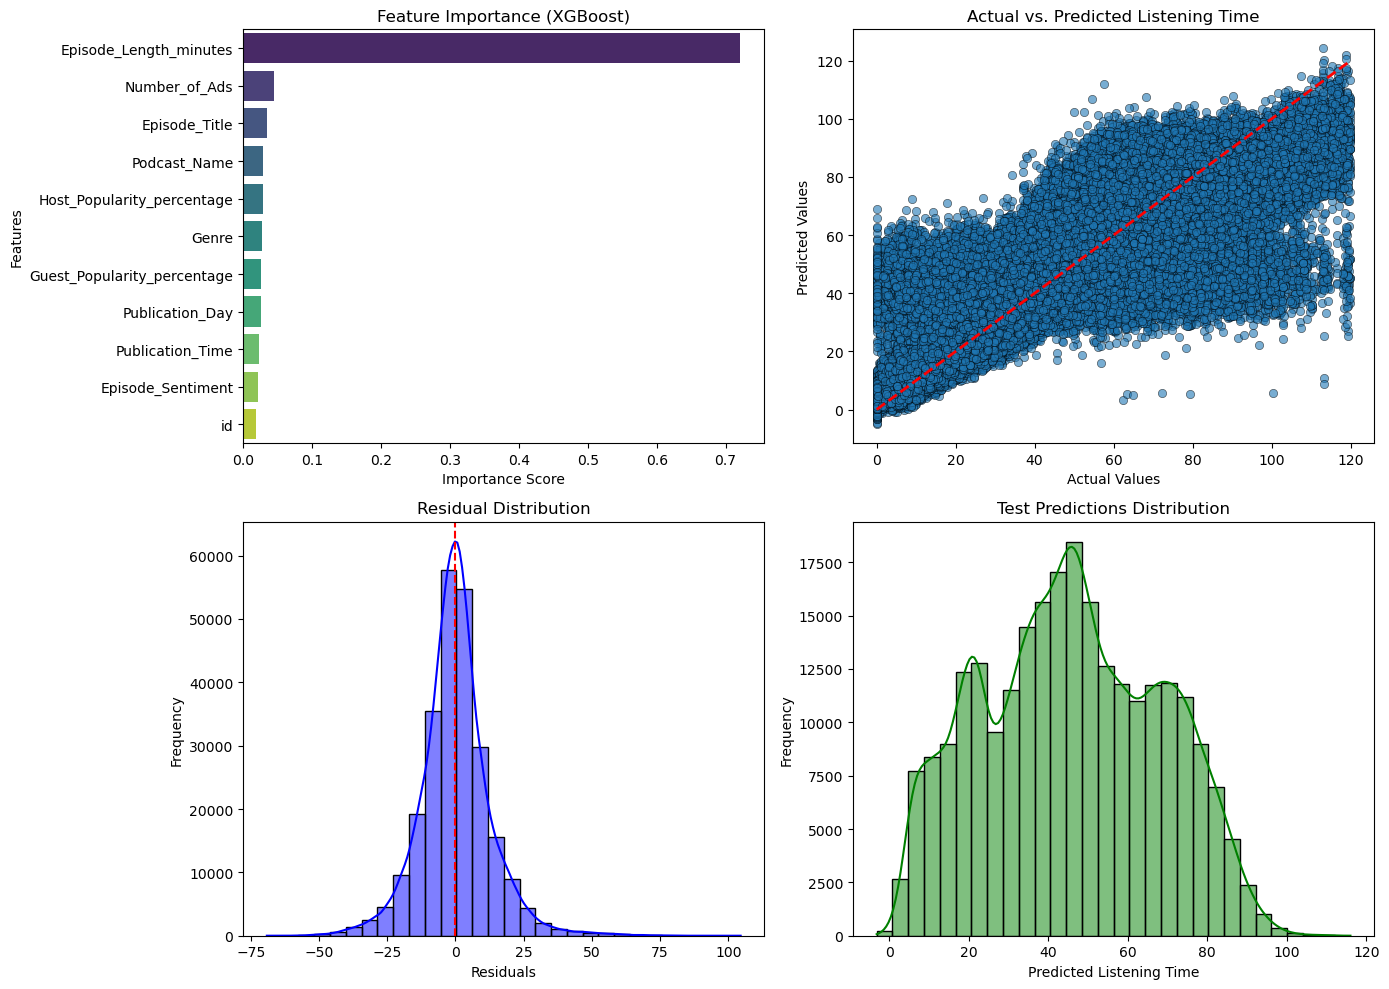

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

feature_importance = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Feature Importance (XGBoost)")
axes[0, 0].set_xlabel("Importance Score")
axes[0, 0].set_ylabel("Features")

sns.scatterplot(x=y_val, y=val_pred, alpha=0.6, edgecolors="k", ax=axes[0, 1])
axes[0, 1].plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], '--r', linewidth=2) 
axes[0, 1].set_title("Actual vs. Predicted Listening Time")
axes[0, 1].set_xlabel("Actual Values")
axes[0, 1].set_ylabel("Predicted Values")

residuals = y_val - val_pred
sns.histplot(residuals, bins=30, kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Frequency")

sns.histplot(test_preds, bins=30, kde=True, color='green', ax=axes[1, 1])
axes[1, 1].set_title("Test Predictions Distribution")
axes[1, 1].set_xlabel("Predicted Listening Time")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### [Feature Insight Trick 🪄🔍](https://www.kaggle.com/code/tylerfeemster/feature-insight-trick/notebook)

In [7]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from scipy.stats import chi2

class Files:
    train = 'data/train.csv'
    test = 'data/test.csv'

data = pd.read_csv(Files.train, index_col='id')
target = 'Listening_Time_minutes'

X = data.drop([target], axis=1)
y = data[target]

In [17]:
def traverse(node, parents, ancestors):
    # Select non-leaf nodes
    if 'split_feature' in node:
        feature = node['split_feature']
        for parent in parents:
            ancestors.append((parent, feature))

        parents = parents.copy()
        parents.append(feature)
    
        if 'left_child' in node:
            traverse(node['left_child'], parents, ancestors)
        
        if 'right_child' in node:
            traverse(node['right_child'], parents, ancestors)


def tally_results(ancestors, num_features, doubled = False):
    parent_count, child_count, tuple_count = {}, {}, {}
    total = 0

    for p, c in ancestors:
        total += 1
        parent_count[p] = parent_count.get(p, 0) + 1
        child_count[c] = child_count.get(c, 0) + 1
        tuple_count[(p, c)] = tuple_count.get((p, c), 0) + 1

    p_vals = {}
    dof = (num_features - 1) ** 2   # Degree of Freedom
    for (p, c), observed in tuple_count.items():
        if doubled:
            if (c, p) in p_vals:
                continue
            
            expected = (parent_count[p] * child_count[c] + parent_count[c] * child_count[p]) / total
            try:
                observed += tuple_count[(c, p)]
            except:
                pass
        else:
            expected = parent_count[p] * child_count[c] / total
        
        chi2_stat = (observed - expected) ** 2 / expected
        p_vals[(p, c)] = (1 - chi2.cdf(chi2_stat, df=dof), "Attractive" if observed > expected else "Repulsive")

    df_items = [{'Parent': p, 'Child': c, 'Relationship': freq, 'p_value': val} for (p, c), (val, freq) in p_vals.items()]

    return pd.DataFrame(df_items)

In [18]:
def ranked_feature_relationship(X, y, doubled=False):
    X, y = X.copy(), y.copy()

    cat_cols = X.select_dtypes(include='object').columns.to_list()
    
    X[cat_cols] = X[cat_cols].astype('category')

    features = X.columns.tolist()

    dtrain = lgb.Dataset(X, label=y, categorical_feature=cat_cols)

    params = {
        'objective': 'regression',
        'boosting': 'gbdt',
        'verbose': -1,
        'max_depth': 5,
    }

    # Train the LightGBM model
    model = lgb.train(params, dtrain, num_boost_round=1000)

    trees = model.dump_model()["tree_info"]
    ancestors = []
    for tree in trees:
        parents = []
        traverse(tree["tree_structure"], parents, ancestors)
    
    p_values = tally_results(ancestors, len(features), doubled=doubled)

    # Subsititute the feature indexes with the actual feature names
    p_values[['Parent', 'Child']] = p_values[['Parent', 'Child']].map(lambda x: features[x])

    p_values = p_values.sort_values('p_value', ascending=True).reset_index(drop=True)

    if doubled:
        p_values = p_values.rename(columns={'Parent' : 'Feature_1', 'Child' : 'Feature_2'})
    return p_values

In [19]:
p_vals = ranked_feature_relationship(X, y)
p_vals.query("Parent != Child and p_value < 0.05").reset_index(drop=True).head(20)

,Parent,Child,Relationship,p_value
0,Episode_Length_minutes,Number_of_Ads,Attractive,0.000000e+00
1,Episode_Title,Podcast_Name,Attractive,0.000000e+00
2,Podcast_Name,Episode_Title,Attractive,0.000000e+00
3,Episode_Title,Episode_Length_minutes,Attractive,4.274359e-13
4,Podcast_Name,Episode_Length_minutes,Attractive,2.473424e-10
5,Host_Popularity_percentage,Publication_Day,Repulsive,3.707695e-09
6,Podcast_Name,Publication_Day,Attractive,7.707409e-05
7,Guest_Popularity_percentage,Publication_Day,Repulsive,2.792019e-02


This is empirical evidence that we should spend some time looking into combining these feature pairs.
Attractive

- (0/1) For those who've done some EDA, (Podcast_Name, Episode_Title) is not uniquely identifying. In fact, each pair has lots of datapoints. We can experiment with feature concatenation here.
- (2) The model likes splitting on Number_of_Ads after Episode_Length_minutes has been refined. This is intuitive; ad frequency is a more important measure.
- (3/4) Both Podcast_Name and Episode_Title like to split with Episode_Length_minutes. Considering (0/1), maybe there is a 3-way relationship to explore with these. The most likely explanation is that knowing the episode length is more informative/useful once we know which podcast/episode it is.
- (6) Interesting. Publication_Day is more useful after knowing the podcast. Concatenation here?

Repulsive

- (5/7) Knowing either the host or guest popularity reduces the partial predictiveness of Publication_Day. Maybe people are just happier listening on certain days? We could try standardizing the popularities according to the publication day?

In [20]:
p_vals.query('Parent == Child and p_value < 0.05').reset_index(drop=True).head(20)

,Parent,Child,Relationship,p_value
0,Episode_Length_minutes,Episode_Length_minutes,Repulsive,0.0
1,Host_Popularity_percentage,Host_Popularity_percentage,Attractive,0.0
2,Guest_Popularity_percentage,Guest_Popularity_percentage,Attractive,0.0
3,Episode_Title,Episode_Title,Repulsive,0.0
4,Podcast_Name,Podcast_Name,Repulsive,0.0


In [21]:
# Symmetric Feature Interactions

symmetric_p_vals = ranked_feature_relationships(X, y, doubled=True)
symmetric_p_vals.query('Feature_1 != Feature_2 and p_value < 0.05').reset_index(drop=True).head(20)

,Feature_1,Feature_2,Relationship,p_value
0,Episode_Length_minutes,Number_of_Ads,Attractive,0.000000e+00
1,Episode_Length_minutes,Episode_Title,Attractive,0.000000e+00
2,Episode_Title,Podcast_Name,Attractive,0.000000e+00
3,Host_Popularity_percentage,Publication_Day,Repulsive,4.218847e-15
4,Episode_Length_minutes,Podcast_Name,Attractive,4.279732e-11
5,Host_Popularity_percentage,Guest_Popularity_percentage,Repulsive,2.996671e-07
6,Guest_Popularity_percentage,Publication_Day,Repulsive,1.018816e-05
7,Publication_Day,Episode_Title,Attractive,2.595983e-04
8,Publication_Day,Podcast_Name,Attractive,1.359488e-03


In [22]:
symmetric_p_vals.query('Feature_1 == Feature_2 and p_value < 0.05').reset_index(drop=True).head(20)

,Feature_1,Feature_2,Relationship,p_value
0,Episode_Length_minutes,Episode_Length_minutes,Repulsive,0.000000
1,Host_Popularity_percentage,Host_Popularity_percentage,Attractive,0.000000
2,Guest_Popularity_percentage,Guest_Popularity_percentage,Attractive,0.000000
3,Episode_Title,Episode_Title,Repulsive,0.000000
4,Podcast_Name,Podcast_Name,Repulsive,0.000000
5,Publication_Day,Publication_Day,Repulsive,0.002487
